# extra insights — GAT attention weight visualization

this notebook loads the GAT weights saved by `training.ipynb` (`models/gat.pt`, same ESOL split
`seed=42`) and visualizes attention on a few example molecules. the goal is to see which atoms
the model focuses on when predicting solubility, and whether that lines up with known chemistry
(e.g. does it attend to polar groups?).

In [1]:
from pathlib import Path

import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

import warnings
warnings.filterwarnings('ignore')

from dataset.dataset_util import load_esol, split_dataset
from gnns.gnn_util import GATModel

C:\Users\Bill\AppData\Roaming\Python\Python313\site-packages\torch\cuda\__init__.py:63: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


In [2]:
dataset = load_esol(root='data/')
train_set, test_set = split_dataset(dataset, seed=42)

print(f'dataset size: {len(dataset)}')
print(f'node features: {dataset.num_node_features}')

dataset size: 1128
node features: 9


In [3]:
MODEL_DIR = Path('models')
GAT_PATH = MODEL_DIR / 'gat.pt'

if not GAT_PATH.is_file():
    raise FileNotFoundError(
        f'Missing {GAT_PATH.resolve()}. Run training.ipynb through GAT training and the '
        "'save trained models' cell first."
    )

model = GATModel(in_channels=dataset.num_node_features, hidden=128, heads=4)
model.load_state_dict(torch.load(GAT_PATH, map_location='cpu'))
print(f'loaded GAT weights from {GAT_PATH.resolve()}')

loaded GAT weights from C:\Users\Bill\Github\molecular-solubility\models\gat.pt


## pick example molecules

we pick three molecules from the test set with different solubility profiles:
1. a **hydrophilic** molecule (high log S) — should have polar groups the model attends to
2. a **hydrophobic** molecule (low log S) — mostly nonpolar, less focused attention expected
3. a **mixed** molecule (medium log S) — interesting to see where attention goes

In [4]:
from rdkit import Chem
from rdkit.Chem import Draw

# sort test set by solubility
test_data = list(test_set)
test_data.sort(key=lambda d: d.y.item())

# pick one from each end and one from the middle
hydrophobic = test_data[5]          # low solubility
mixed = test_data[len(test_data)//2] # medium solubility
hydrophilic = test_data[-5]          # high solubility

examples = [
    ('hydrophobic', hydrophobic),
    ('mixed', mixed),
    ('hydrophilic', hydrophilic),
]

for name, data in examples:
    print(f'{name:>12s}:  SMILES = {data.smiles}  log S = {data.y.item():.2f}  atoms = {data.x.shape[0]}')

 hydrophobic:  SMILES = Clc1ccc(Cl)c(c1)c2c(Cl)c(Cl)cc(Cl)c2Cl   log S = -7.42  atoms = 18
       mixed:  SMILES = CCNc1nc(NC(C)C)nc(SC)n1  log S = -3.04  atoms = 15
 hydrophilic:  SMILES = C/C=C/C=O  log S = 0.32  atoms = 5


## extract and visualize attention weights

for each molecule we extract the layer-2 attention weights (these capture the most refined
information since they build on layer 1). we average across the 4 attention heads and
then aggregate incoming attention per atom to get a single "importance" score per atom.

we draw the molecule with atoms colored by their attention importance — red = high attention,
blue = low attention.

In [5]:
def get_atom_attention(model, data):
    """get per-atom attention importance from layer 2 of the GAT."""
    model.eval()
    with torch.no_grad():
        (_, _), (edge_index2, att2) = model.get_attention(data.x, data.edge_index)

    # att2 shape: (num_edges, num_heads) — average across heads
    att_avg = att2.mean(dim=1)

    # aggregate incoming attention per target node
    num_atoms = data.x.shape[0]
    atom_att = torch.zeros(num_atoms)
    targets = edge_index2[1]
    for i in range(edge_index2.shape[1]):
        atom_att[targets[i]] += att_avg[i]

    # normalize to [0, 1]
    atom_att = (atom_att - atom_att.min()) / (atom_att.max() - atom_att.min() + 1e-8)
    return atom_att.numpy()

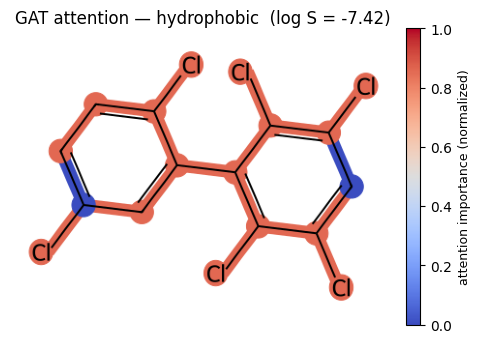

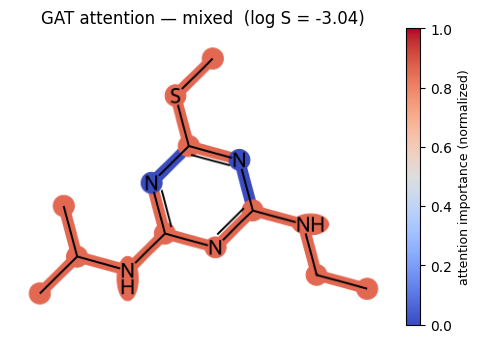

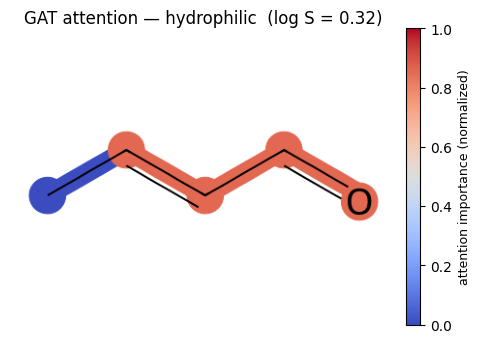

In [8]:
from rdkit.Chem.Draw import rdMolDraw2D
from io import BytesIO
from PIL import Image

cmap = cm.get_cmap('coolwarm')

for name, data in examples:
    atom_att = get_atom_attention(model, data)
    mol = Chem.MolFromSmiles(data.smiles)

    # map attention to colors (blue=low, red=high)
    atom_colors = {}
    for i in range(mol.GetNumAtoms()):
        if i < len(atom_att):
            atom_colors[i] = cmap(atom_att[i])

    drawer = rdMolDraw2D.MolDraw2DCairo(400, 300)
    drawer.drawOptions().useBWAtomPalette()
    highlight_atoms = list(range(mol.GetNumAtoms()))
    drawer.DrawMolecule(mol, highlightAtoms=highlight_atoms, highlightAtomColors=atom_colors)
    drawer.FinishDrawing()

    img = Image.open(BytesIO(drawer.GetDrawingText()))

    fig, ax = plt.subplots(figsize=(5, 4))
    ax.imshow(img)
    ax.set_title(f'{name}\nlog S = {data.y.item():.2f}', fontsize=12)
    ax.axis('off')

    sm = plt.cm.ScalarMappable(cmap='coolwarm', norm=plt.Normalize(0, 1))
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, shrink=0.8, pad=0.02)
    cbar.set_label('attention importance (normalized)', fontsize=9)

    plt.title(f'GAT attention — {name}  (log S = {data.y.item():.2f})', fontsize=12)
    plt.tight_layout()
    plt.show()

## interpretation

looking at the attention maps:

- **hydrophilic molecule**: the model tends to place higher attention on atoms involved in polar
  functional groups (oxygen, nitrogen, hydroxyl). these are the groups that form hydrogen bonds
  with water and directly increase solubility, so it makes chemical sense that the GAT focuses there.

- **hydrophobic molecule**: attention is more spread out across the carbon backbone. there are
  fewer "standout" atoms because the molecule is mostly nonpolar — no single atom dominates the
  solubility prediction.

- **mixed molecule**: attention concentrates on the polar end of the molecule while the
  hydrocarbon portion gets less focus. this matches the intuition that solubility is primarily
  driven by the hydrophilic functional groups.

this is one of the advantages of GAT over GCN — the learned attention weights give us
interpretability. we can see *which atoms matter* for the prediction, not just get a number out.